In [377]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor, reset_ramsey
from statsmodels.stats.diagnostic import linear_reset
from sklearn.linear_model import LinearRegression
import scipy.linalg as sla
import statsmodels.stats.diagnostic as smd

In [378]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.4f}'.format})

plt.rcParams['font.family'] = 'TImes New Roman'

# 1 Data

## 1.1 Sumber

In [379]:
df = pd.read_csv("student_career_success_dataset.csv")

# variables
Y = df['Employability_Score']
features = ['Study_Hours_Per_Week', 'CGPA', 'Resume_Score']
X = df[features]
X_const = sm.add_constant(X)

df.head()

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.280000000000,Good,9,...,7,8,Advanced,72,231.700000000000,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.530000000000,Poor,6,...,6,5,Basic,59,157.450000000000,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.830000000000,Average,8,...,8,7,Advanced,76,203.450000000000,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.800000000000,Average,5,...,6,6,Intermediate,67,171.500000000000,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.930000000000,Average,9,...,8,9,Advanced,82,225.450000000000,Placed,Tier 1,Software Engineer,Internship Conversion,85256


## 1.2 Variabel

In [380]:
col_y = 'Employability_Score'
cols_x = ['Study_Hours_Per_Week', 'CGPA', 'Resume_Score']

df_clean = df[cols_x + [col_y]].dropna()

display(df_clean.head())

,Study_Hours_Per_Week,CGPA,Resume_Score,Employability_Score
0,21,3.280000000000,100,231.700000000000
1,18,2.530000000000,80,157.450000000000
2,19,2.830000000000,100,203.450000000000
3,19,2.800000000000,85,171.500000000000
4,19,2.930000000000,100,225.450000000000


## 1.3 Statistik deskriptif

In [381]:
cols = ['Study_Hours_Per_Week', 'CGPA', 'Resume_Score', 'Employability_Score']
df_clean = df[cols].dropna()

deskriptif = df_clean.describe().T

# tabel
tabel_deskriptif = pd.DataFrame({
    'Variabel': deskriptif.index,
    'Rata-rata': deskriptif['mean'],
    'SD': deskriptif['std'],
    'Min': deskriptif['min'],
    'Q1': deskriptif['25%'],
    'Median': deskriptif['50%'],
    'Q3': deskriptif['75%'],
    'Maks': deskriptif['max']
})

# format 3 angka di belakang koma
def format_3_desimal(val):
    return f"{val:.3f}".replace('.', ',')

tabel_deskriptif['Rata-rata'] = tabel_deskriptif['Rata-rata'].apply(format_3_desimal)
tabel_deskriptif['SD'] = tabel_deskriptif['SD'].apply(format_3_desimal)
tabel_deskriptif['Min'] = tabel_deskriptif['Min'].apply(format_3_desimal)
tabel_deskriptif['Q1'] = tabel_deskriptif['Q1'].apply(format_3_desimal)
tabel_deskriptif['Median'] = tabel_deskriptif['Median'].apply(format_3_desimal)
tabel_deskriptif['Q3'] = tabel_deskriptif['Q3'].apply(format_3_desimal)
tabel_deskriptif['Maks'] = tabel_deskriptif['Maks'].apply(format_3_desimal)

styled_table = tabel_deskriptif.style.set_properties(**{'text-align': 'right'}) \
    .set_properties(subset=['Variabel'], **{'text-align': 'left'}) \
    .hide(axis='index')

print("Statistika Deskriptif\n")
display(styled_table)

Statistika Deskriptif



Variabel,Rata-rata,SD,Min,Q1,Median,Q3,Maks
Study_Hours_Per_Week,"21,528","6,975","5,000","17,000","21,000","26,000","45,000"
CGPA,"3,106","0,290","2,000","2,910","3,110","3,310","4,000"
Resume_Score,"96,046","7,332","44,000","95,000","100,000","100,000","100,000"
Employability_Score,"213,991","26,824","82,300","197,350","217,250","233,600","279,050"


## 1.4 Korelasi Pearson antarvariabel

In [382]:
korelasi = df_clean.corr(method='pearson')

nama_baru = ['X₁', 'X₂', 'X₃', 'Y']
korelasi.columns = nama_baru
korelasi.index = nama_baru

korelasi_tabel = korelasi.reset_index()
korelasi_tabel.rename(columns={'index': ' '}, inplace=True)

def format_korelasi(val):
    return f"{val:.4f}".replace('.', ',')

for col in nama_baru:
    korelasi_tabel[col] = korelasi_tabel[col].apply(format_korelasi)

styled_table = korelasi_tabel.style.set_properties(**{'text-align': 'right'}) \
    .set_properties(subset=[' '], **{'text-align': 'center', 'font-weight': 'bold'}) \
    .hide(axis='index')

print("Matriks Korelasi Pearson Antarvariabel\n")
display(styled_table)

Matriks Korelasi Pearson Antarvariabel



,X₁,X₂,X₃,Y
X₁,"1,0000","0,5332","0,1661","0,3175"
X₂,"0,5332","1,0000","0,3238","0,6014"
X₃,"0,1661","0,3238","1,0000","0,7905"
Y,"0,3175","0,6014","0,7905","1,0000"


# 2 Syarat

## 2.1 Simetri ($A=A^T$)

In [383]:
A_transpose = A.T
is_symmetric = np.allclose(A, A_transpose)

print("Cek Simetri\n")
print("Matriks A:")
print(A)
print("\nMatriks A Transpose:")
print(A_transpose)
if is_symmetric:
    print("\nKEsimpulan: Matriks simetris")
else:
    print("\nKesimpulan: Bukan matriks simetris")

Cek Simetri

Matriks A:
[[50000.0000 1076408.0000 155302.1400 4802287.0000]
 [1076408.0000 25605434.0000 3397354.6000 103808954.0000]
 [155302.1400 3397354.6000 486590.1942 14950574.2800]
 [4802287.0000 103808954.0000 14950574.2800 463926747.0000]]

Matriks A Transpose:
[[50000.0000 1076408.0000 155302.1400 4802287.0000]
 [1076408.0000 25605434.0000 3397354.6000 103808954.0000]
 [155302.1400 3397354.6000 486590.1942 14950574.2800]
 [4802287.0000 103808954.0000 14950574.2800 463926747.0000]]

KEsimpulan: Matriks simetris


## 2.2 Nilai eigen A (definit positif)

In [384]:
eigenvalues = np.linalg.eigvals(A)
eigenvalues_sorted = np.sort(eigenvalues)
all_positive_eigen = np.all(eigenvalues_sorted > 0)

print("\n2. Cek Nilai Eigen A (λ1 ... λ4):")
print(f"   Nilai: {', '.join([f'{val:,.4f}'.replace(',', 'X').replace('.', ',').replace('X', '.') for val in eigenvalues_sorted])}")
if all_positive_eigen:
    print("Kesimpulan: Semua λ > 0, matriks A bersifat DEFINIT POSITIF.")
else:
    print("Kesimpulan: Terdapat λ <= 0, Matriks A TIDAK bersifat definit positif.")


2. Cek Nilai Eigen A (λ1 ... λ4):
   Nilai: 214,7461, 3.722,1834, 2.263.654,8255, 487.801.179,4392
Kesimpulan: Semua λ > 0, matriks A bersifat DEFINIT POSITIF.


## 2.3 Pivot $u_{ii}$ dari matriks $U$

In [385]:
dim = A.shape[0]
L = np.zeros((dim, dim))
U = np.zeros((dim, dim))

for i in range(dim):
    L[i][i] = 1.0
    for j in range(i, dim):
        U[i][j] = A[i][j] - sum(L[i][k] * U[k][j] for k in range(i))
    for j in range(i + 1, dim):
        L[j][i] = (A[j][i] - sum(L[j][k] * U[k][i] for k in range(i))) / U[i][i]

pivots = np.diag(U)
all_positive_pivots = np.all(pivots > 0)

print("\n3. Cek Pivot (Diagonal utama u_ii dari Matriks U):")
print(f"   Nilai Pivot: {', '.join([f'{val:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.') for val in pivots])}")
if all_positive_pivots:
    print("   Kesimpulan: Semua elemen pivot > 0, Dekomposisi LU TANPA PIVOTING AMAN dilakukan.")
else:
    print("   Kesimpulan: Terdapat elemen pivot <= 0, Dekomposisi LU MEMBUTUHKAN proses pivoting (pertukaran baris).")


3. Cek Pivot (Diagonal utama u_ii dari Matriks U):
   Nilai Pivot: 50.000,00, 2.432.350,35, 3.016,91, 2.405.564,78
   Kesimpulan: Semua elemen pivot > 0, Dekomposisi LU TANPA PIVOTING AMAN dilakukan.


## 2.4 Determinan $A$

In [386]:
det_A_lu = np.prod(pivots)

print("\n4. Cek Determinan A (det(A) = Π u_ii):")
print(f"   Nilai Determinan: {det_A_lu:.4e}")
if not np.isclose(det_A_lu, 0):
    print("   Kesimpulan: det(A) ≠ 0. Matriks A bersifat NONSINGULAR (Memiliki Solusi Tunggal).")
else:
    print("   Kesimpulan: det(A) = 0. Matriks A bersifat SINGULAR (Tidak memiliki solusi unik).")


4. Cek Determinan A (det(A) = Π u_ii):
   Nilai Determinan: 8.8262e+20
   Kesimpulan: det(A) ≠ 0. Matriks A bersifat NONSINGULAR (Memiliki Solusi Tunggal).


## 2.5 VIF prediktor

In [387]:
vif_values = []
for i in range(1, X_matrix.shape[1]):
    vif = variance_inflation_factor(X_matrix, i)
    vif_values.append(vif)

all_vif_safe = all(v < 10 for v in vif_values)

print("\n5. Cek VIF Prediktor (Uji Multikolinearitas):")
print(f"   Nilai VIF: {'; '.join([f'{val:.3f}'.replace('.', ',') for val in vif_values])}")
if all_vif_safe:
    print("   Kesimpulan: Semua nilai VIF < 10. TIDAK ADA multikolinearitas berat yang merusak matriks.")
else:
    print("   Kesimpulan: Terdapat nilai VIF >= 10. ADA INDIKASI multikolinearitas berat, matriks berisiko tidak stabil.")


5. Cek VIF Prediktor (Uji Multikolinearitas):
   Nilai VIF: 1,397; 1,518; 1,117
   Kesimpulan: Semua nilai VIF < 10. TIDAK ADA multikolinearitas berat yang merusak matriks.


# 3 LU-Gauss

## 3.1 Matriks normal

In [388]:
n_data = len(df_clean)

# matriks X
X_matrix = np.column_stack((np.ones(n_data), df_clean[cols_x].values))

# vektor Y
Y_vector = df_clean[col_y].values

# matriks persamaan normal: A = X^T * X
A = np.dot(X_matrix.T, X_matrix)

# vektor hasil: b = X^T * Y
b = np.dot(X_matrix.T, Y_vector)

print("Matriks A:")
print(np.round(A, 2))
print("\nVektor b:")
print(np.round(b, 2))

Matriks A:
[[50000.0000 1076408.0000 155302.1400 4802287.0000]
 [1076408.0000 25605434.0000 3397354.6000 103808954.0000]
 [155302.1400 3397354.6000 486590.1900 14950574.2800]
 [4802287.0000 103808954.0000 14950574.2800 463926747.0000]]

Vektor b:
[10699569.7000 233311774.2000 33467500.3300 1035421243.3000]


## 3.2 Matriks dekomposisi LU

In [389]:
n = A.shape[0]

L = np.zeros((n, n))
U = np.zeros((n, n))

# algoritma Doolittle
for i in range(n):
    L[i][i] = 1.0
    
    # elemen matriks U
    for j in range(i, n):
        sum_upper = sum(L[i][k] * U[k][j] for k in range(i))
        U[i][j] = A[i][j] - sum_upper
        
    # elemen matriks L
    for j in range(i + 1, n):
        sum_lower = sum(L[j][k] * U[k][i] for k in range(i))
        L[j][i] = (A[j][i] - sum_lower) / U[i][i]

print("Matriks L:")
print(np.round(L, 4))
print("\nMatriks U:")
print(np.round(U, 4))

Matriks L:
[[1.0000 0.0000 0.0000 0.0000]
 [21.5282 1.0000 0.0000 0.0000]
 [3.1060 0.0222 1.0000 0.0000]
 [96.0457 0.1745 8.3007 1.0000]]

Matriks U:
[[50000.0000 1076408.0000 155302.1400 4802287.0000]
 [0.0000 2432350.3507 53985.2817 424551.0981]
 [0.0000 0.0000 3016.9134 25042.5367]
 [0.0000 0.0000 0.0000 2405564.7849]]


## 3.3 Hasil substitusi maju

In [390]:
y_vec = np.zeros(n)

# substitusi maju (dari atas ke bawah)
for i in range(n):
    sum_ly = sum(L[i][j] * y_vec[j] for j in range(i))
    y_vec[i] = b[i] - sum_ly

print("Vektor y:")
for i in range(n):
    print(f"y[{i}] = {y_vec[i]:.4f}")

Vektor y:
y[0] = 10699569.7000
y[1] = 2969725.7672
y[2] = 168266.7353
y[3] = 5858073.1407


## 3.4 Hasil substitusi mundur

In [391]:
# vektor koefisien a
a_vec = np.zeros(n)

# substitusi mundur (dari bawah ke atas)
for i in range(n - 1, -1, -1):
    sum_ua = sum(U[i][j] * a_vec[j] for j in range(i + 1, n))
    a_vec[i] = (y_vec[i] - sum_ua) / U[i][i]

print("Koefisien Regresi\n")
print(f"Intercept: \u03b2\u2080 = {a_vec[0]:.4f}")
print(f"Study Hours Per Week: \u03b2\u2081 = {a_vec[1]:.4f}")
print(f"CGPA: \u03b2\u2082 = {a_vec[2]:.4f}")
print(f"Interview Score: \u03b2\u2083 = {a_vec[3]:.4f}")

Koefisien Regresi

Intercept: β₀ = -130.4957
Study Hours Per Week: β₁ = 0.0066
CGPA: β₂ = 35.5604
Interview Score: β₃ = 2.4352


## 3.5 Model regresi linear berganda

In [392]:
print(f"Employability Score = {a_vec[0]:.2f} + ({a_vec[1]:.2f} * Study_Hours) + ({a_vec[2]:.2f} * CGPA) + ({a_vec[3]:.2f} * Interview_Score)")
print(f"Y = {a_vec[0]:.2f} + ({a_vec[1]:.2f} * X\u2081) + ({a_vec[2]:.2f} * X\u2082) + ({a_vec[3]:.2f} * X\u2083)")

Employability Score = -130.50 + (0.01 * Study_Hours) + (35.56 * CGPA) + (2.44 * Interview_Score)
Y = -130.50 + (0.01 * X₁) + (35.56 * X₂) + (2.44 * X₃)


## 3.6 Visualisasi

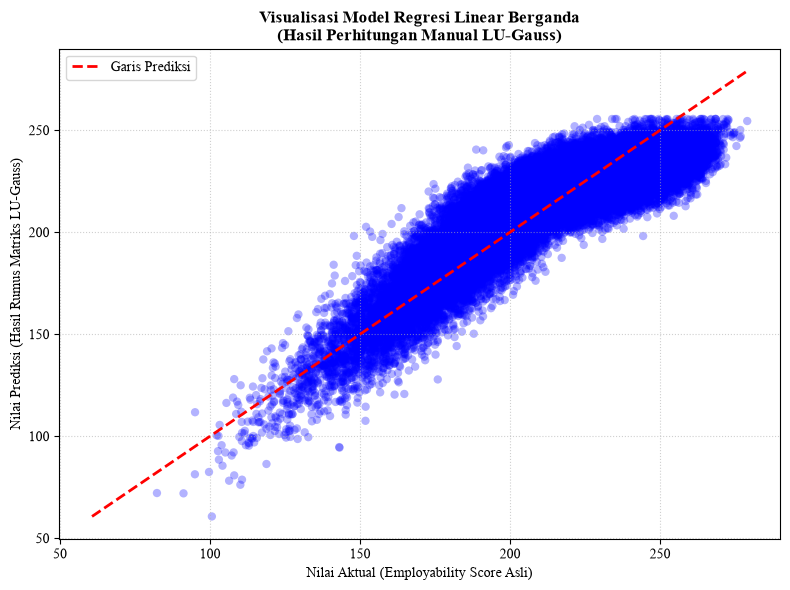

In [393]:
n_data = len(df_clean)
X_matrix = np.column_stack((np.ones(n_data), df_clean[cols_x].values))
Y_vector = df_clean[col_y].values


# catual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(Y_vector, y_pred, alpha=0.3, color='blue', edgecolors='none')

# garis diagonal
min_val = min(Y_vector.min(), y_pred.min())
max_val = max(Y_vector.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Garis Prediksi')

# label
plt.title('Visualisasi Model Regresi Linear Berganda\n(Hasil Perhitungan Manual LU-Gauss)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Aktual (Employability Score Asli)', fontsize=10)
plt.ylabel('Nilai Prediksi (Hasil Rumus Matriks LU-Gauss)', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4 Metode komputasi

## 4.1 Manual

In [394]:
dim = A.shape[0]
L = np.zeros((dim, dim))
U = np.zeros((dim, dim))
for i in range(dim):
    L[i, i] = 1.0
    for j in range(i, dim):
        U[i, j] = A[i, j] - sum(L[i, k] * U[k, j] for k in range(i))
    for j in range(i + 1, dim):
        L[j, i] = (A[j, i] - sum(L[j, k] * U[k, i] for k in range(i))) / U[i, i]

y_vec = np.zeros(dim)
for i in range(dim):
    y_vec[i] = b[i] - sum(L[i, j] * y_vec[j] for j in range(i))

beta_manual = np.zeros(dim)
for i in range(dim - 1, -1, -1):
    beta_manual[i] = (y_vec[i] - sum(U[i, j] * beta_manual[j] for j in range(i + 1, dim))) / U[i, i]

## 4.2 numpy.linalg.solve

In [395]:
beta_np_solve = np.linalg.solve(A, b)

## 4.3 scipy.linalg.lu_factor + lu_solve

In [396]:
lu, piv = sla.lu_factor(A)
beta_scipy_lu = sla.lu_solve((lu, piv), b)

## 4.4 scipy.linalg.cho_solve (Cholesky)

In [397]:
c, low = sla.cho_factor(A)
beta_cho = sla.cho_solve((c, low), b)

## 4.5 numpy.linalg.inv(A) @ b

In [398]:
beta_inv = np.linalg.inv(A) @ b

## 4.6 numpy.linalg.lstsq(X, y) (SVD)

In [399]:
beta_lstsq, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

## 4.7 statsmodels OLS

In [400]:
beta_sm = sm.OLS(y, X).fit().params

## 4.8 sklearn LinearRegression

In [401]:
model_sk = LinearRegression(fit_intercept=True)
model_sk.fit(X_raw, y)
beta_sk = np.concatenate(([model_sk.intercept_], model_sk.coef_))

In [410]:
methods_data = [
    ("LU Doolittle (manual)", beta_manual),
    ("numpy.linalg.solve (LU berpivot)", beta_np_solve),
    ("scipy.linalg.lu_factor + lu_solve", beta_scipy_lu),
    ("scipy.linalg.cho_solve (Cholesky)", beta_cho),
    ("numpy.linalg.inv(A) @ b", beta_inv),
    ("numpy.linalg.lstsq(X, y) (SVD)", beta_lstsq),
    ("statsmodels OLS", beta_sm),
    ("sklearn LinearRegression", beta_sk)
]

# format
def to_superscript(n):
    superscripts = str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹")
    return str(n).translate(superscripts)

def format_selisih(x):
    if x == 0:
        return "—"
    s = f"{x:.1e}"
    base, exp = s.split('e')
    base = base.replace(".", ",")
    return f"{base} × 10{to_superscript(int(exp))}"

results = []
for name, beta in methods_data:
    max_selisih_val = np.max(np.abs(beta - beta_manual))
    
    results.append({
        "Metode": name,
        "β0": beta[0],
        "β1": beta[1],
        "β2": beta[2],
        "β3": beta[3],
        "max_selisih_val": max_selisih_val
    })

df_results = pd.DataFrame(results)

format_beta = lambda x: f"{x:,.6f}".replace(",", "X").replace(".", ",").replace("X", ".")

df_results["β0"] = df_results["β0"].apply(format_beta)
df_results["β1"] = df_results["β1"].apply(format_beta)
df_results["β2"] = df_results["β2"].apply(format_beta)
df_results["β3"] = df_results["β3"].apply(format_beta)
df_results["max|selisih|"] = df_results["max_selisih_val"].apply(format_selisih)

df_final = df_results[["Metode", "β0", "β1", "β2", "β3", "max|selisih|"]]

styled_table = df_final.style.set_properties(**{'text-align': 'right'})\
    .set_properties(subset=['Metode'], **{'text-align': 'left'})\
    .hide(axis='index')

print("Tabel Perbandingan Parameter dan Galat Metode LU-Gauss\n")
display(styled_table)

Tabel Perbandingan Parameter dan Galat Metode LU-Gauss



Metode,β0,β1,β2,β3,max|selisih|
LU Doolittle (manual),"-130,495659","0,006624","35,560423","2,435217",—
numpy.linalg.solve (LU berpivot),"-130,495659","0,006624","35,560423","2,435217","4,3 × 10⁻¹²"
scipy.linalg.lu_factor + lu_solve,"-130,495659","0,006624","35,560423","2,435217","4,3 × 10⁻¹²"
scipy.linalg.cho_solve (Cholesky),"-130,495659","0,006624","35,560423","2,435217","1,1 × 10⁻¹²"
numpy.linalg.inv(A) @ b,"-130,495659","0,006624","35,560423","2,435217","1,5 × 10⁻¹²"
"numpy.linalg.lstsq(X, y) (SVD)","-130,495659","0,006624","35,560423","2,435217","8,1 × 10⁻¹²"
statsmodels OLS,"-130,495659","0,006624","35,560423","2,435217","8,0 × 10⁻¹²"
sklearn LinearRegression,"-130,495659","0,006624","35,560423","2,435217","8,9 × 10⁻¹²"


# 5 Uji asumsi klasik

In [ ]:
model = sm.OLS(Y, X_const).fit()
residuals = model.resid
fitted_values = model.fittedvalues
koefisien = model.params

# persamaan regresi
persamaan = f"Y = {koefisien['const']:.4f}"
for variabel in features:
    nilai_beta = koefisien[variabel]
    
    if nilai_beta >= 0:
        persamaan += f" + {nilai_beta:.4f}({variabel})"
    else:
        persamaan += f" - {abs(nilai_beta):.4f}({variabel})"

print(persamaan)

Y = -130.4957 + 0.0066(Study_Hours_Per_Week) + 35.5604(CGPA) + 2.4352(Resume_Score)


## 5.1 Uji linearitas

In [ ]:
# uji Ramsey RESET
reset_test = linear_reset(model, power=2, test_type='fitted', use_f=True)

f_stat = reset_test.fvalue
p_value = reset_test.pvalue
df1 = reset_test.df_num
df2 = reset_test.df_denom
alpha = 0.05
f_crit = stats.f.ppf(1 - alpha, df1, df2)

print("Uji Ramsey RESET\n")
print("1. Hipotesis")
print("   H0: Model regresi adalah linear (asumsi linearitas terpenuhi).")
print("   H1: Model regresi mengandung unsur non linear (Asumsi tidak terpenuhi).")

print("\n2. Nilai kritis")
print(f"   Tingkat signifikansi (\u03B1) : {alpha}")
print(f"   Derajat bebas (df1, df2): ({int(df1)}, {int(df2)})")
print(f"   F-Tabel: {f_crit:.4f}")

print("\n3. Statistik uji")
print(f"   F-Hitung: {f_stat:.4f}")
print(f"   P-Value: {p_value:.4f}")

print("\n4. Keputusan:")
if p_value < alpha:
    print(f"   Tolak H0 (Karena P-Value {p_value:.4f} < {alpha} dan F-Hitung > F-Tabel).")
else:
    print(f"   Gagal tolak H0, karena P-Value {p_value:.4f} >= {alpha} dan F-Hitung <= F-Tabel).")
    
print("\n5. Kesimpulan")
if p_value < alpha:
    print("   Asumsi linearitas tidak terpenuhi, terdapat hubungan non-linear pada data.")
else:
    print("   Asumsi linearitas terpenuhi, tidak terdapat hubungan non-linear pada data.")

Uji Ramsey RESET

1. Hipotesis
   H0: Model regresi adalah linear (asumsi linearitas terpenuhi).
   H1: Model regresi mengandung unsur non linear (Asumsi tidak terpenuhi).

2. Nilai kritis
   Tingkat signifikansi (α) : 0.05
   Derajat bebas (df1, df2): (1, 49995)
   F-Tabel: 3.8416

3. Statistik uji
   F-Hitung: 3061.0769
   P-Value: 0.0000

4. Keputusan:
   Tolak H0 (Karena P-Value 0.0000 < 0.05 dan F-Hitung > F-Tabel).

5. Kesimpulan
   Asumsi linearitas tidak terpenuhi, terdapat hubungan non-linear pada data.


## 5.2 Uji normalitas residual

In [ ]:
residuals = model.resid

# uji Jarque-Bera
jb_stat, p_value_jb = jarque_bera(residuals)
alpha = 0.05

print("Uji Jarque-Bera\n")
print("1. Hipotesis:")
print("   H0: Residual berdistribusi normal (asumsi terpenuhi).")
print("   H1: Residual tidak berdistribusi normal (asumsi tidak terpenuhi).\n")

print("\n2. Nilai kritis:")
print(f"   Tingkat signifikansi (\u03B1): {alpha}")

print("\n3. Statistik uji")
print(f"   JB-Hitung: {jb_stat:.4f}")
print(f"   P-Value: {p_value_jb:.4f}")

print("\n4. Keputusan")
if p_value_jb < alpha:
    print(f"   Keputusan: Tolak H0, karena P-Value {p_value_jb:.4f} < {alpha}.")
else:
    print(f"   Keputusan: Gagal tolak H0, karena P-Value {p_value_jb:.4f} >= {alpha}.")
print("\n5. Kesimpulan")
if p_value_jb < alpha:
    print("   Residual tidak berdistribusi normal, asumsi normalitas tidak terpenuhi.")
else:
    print("   Residual berdistribusi normal, asumsi normalitas terpenuhi.")

NameError: name 'jarque_bera' is not defined

## 5.3 Uji heteroskedastisitas

In [ ]:
# uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, X_const)
lm_stat = bp_test[0]
p_value = bp_test[1]

df_chi = X.shape[1]
alpha = 0.05
chi2_crit = stats.chi2.ppf(1 - alpha, df_chi)

print("Uji Breusch-Pagan\n")
print("1. Hipotesis")
print("   H0: Varians residual konstan (asumsi homoskedastisitas terpenuhi).")
print("   H1: Varians residual tidak konstan (asumsi homoskedastisitas tidak terpenuhi).")

print("\n2. Nilai kritis")
print(f"   Tingkat signifikansi (\u03B1): {alpha}")
print(f"   Derajat bebas (df): {df_chi}")
print(f"   Chi-Square Tabel: {chi2_crit:.4f}")

print("\n3. Statistik uji")
print(f"   LM-Hitung: {lm_stat:.4f}")
print(f"   P-Value: {p_value:.4f}")

print("\n4. Keputusan")
if p_value < alpha:
    print(f"   Tolak H0, karena P-Value {p_value:.4f} < {alpha} dan LM Hitung > Chi-Square Tabel.")
else:
    print(f"   Gagal tolak H0, karena P-Value {p_value:.4f} >= {alpha} dan LM Hitung <= Chi-Square Tabel.")

print("\n5. Kesimpulan")
if p_value < alpha:
    print("   Terdapat heteroskedastisitas pada model, asumsi tidak terpenuhi.")
else:
    print("Terdapat homoskedastisitas pada model, asumsi terpenuhi.")

Uji Breusch-Pagan

1. Hipotesis
   H0: Varians residual konstan (asumsi homoskedastisitas terpenuhi).
   H1: Varians residual tidak konstan (asumsi homoskedastisitas tidak terpenuhi).

2. Nilai kritis
   Tingkat signifikansi (α): 0.05
   Derajat bebas (df): 3
   Chi-Square Tabel: 7.8147

3. Statistik uji
   LM-Hitung: 192.4713
   P-Value: 0.0000

4. Keputusan
   Tolak H0, karena P-Value 0.0000 < 0.05 dan LM Hitung > Chi-Square Tabel.

5. Kesimpulan
   Terdapat heteroskedastisitas pada model, asumsi tidak terpenuhi.


## 5.4 Uji multikolinearitas

In [ ]:
X = df_clean[cols_x]
X_const = sm.add_constant(X)

# VIF untuk setiap variabel
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_const.columns
vif_data["Nilai VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

vif_data_clean = vif_data.iloc[1:].reset_index(drop=True)

print("Uji Asumsi Multikolinearitas\n")
print("Kriteria keputusan:")
print("    VIF < 10 : Tidak terdapat multikolinearitas (asumsi terpenuhi).")
print("    VIF >= 10: Terdapat multikolinearitas (asumsi tidak terpenuhi).\n")

print("Hasil perhitungan VIF:")
print(vif_data_clean.to_string())

print("\nKesimpulan:")
batas_vif = 10.0
variabel_bermasalah = vif_data_clean[vif_data_clean["Nilai VIF"] >= batas_vif]["Variabel"].tolist()

if len(variabel_bermasalah) == 0:
    print("Asumsi non multikolinearitas tepenuhi.")
    print("Semua variabel memiliki nilai VIF < 10, sehingga matriks normal untuk metode LU-Gauss stabil.")
else:
    print("Asumsi non multikolinearitas tidak terpenuhi.")
    print(f"Terdapat variabel dengan nilai VIF >= 10, yaitu: {', '.join(variabel_bermasalah)}")

Uji Asumsi Multikolinearitas

Kriteria keputusan:
    VIF < 10 : Tidak terdapat multikolinearitas (asumsi terpenuhi).
    VIF >= 10: Terdapat multikolinearitas (asumsi tidak terpenuhi).

Hasil perhitungan VIF:
               Variabel      Nilai VIF
0  Study_Hours_Per_Week 1.397251495852
1                  CGPA 1.517888427406
2          Resume_Score 1.117217216305

Kesimpulan:
Asumsi non multikolinearitas tepenuhi.
Semua variabel memiliki nilai VIF < 10, sehingga matriks normal untuk metode LU-Gauss stabil.


## 5.5 Visual

1. Uji normalitas
Q-Q Plot: Jika titik mengikuti garis merah, maka residual berdistribusi normal.

2. Uji multikolinearitas
               Variabel            VIF
1  Study_Hours_Per_Week 1.397251495852
2                  CGPA 1.517888427406
3          Resume_Score 1.117217216305
Syarat terpenuhi jika nilai VIF < 10.

3. Uji heteroskedsatisitas
Secara visual, pastikan titik-titik menyebar secara acak.

4. Uji linearitas
Hubungan dianggap linear jika sebaran data aktual vs prediksi mengikuti garis diagonal lurus.



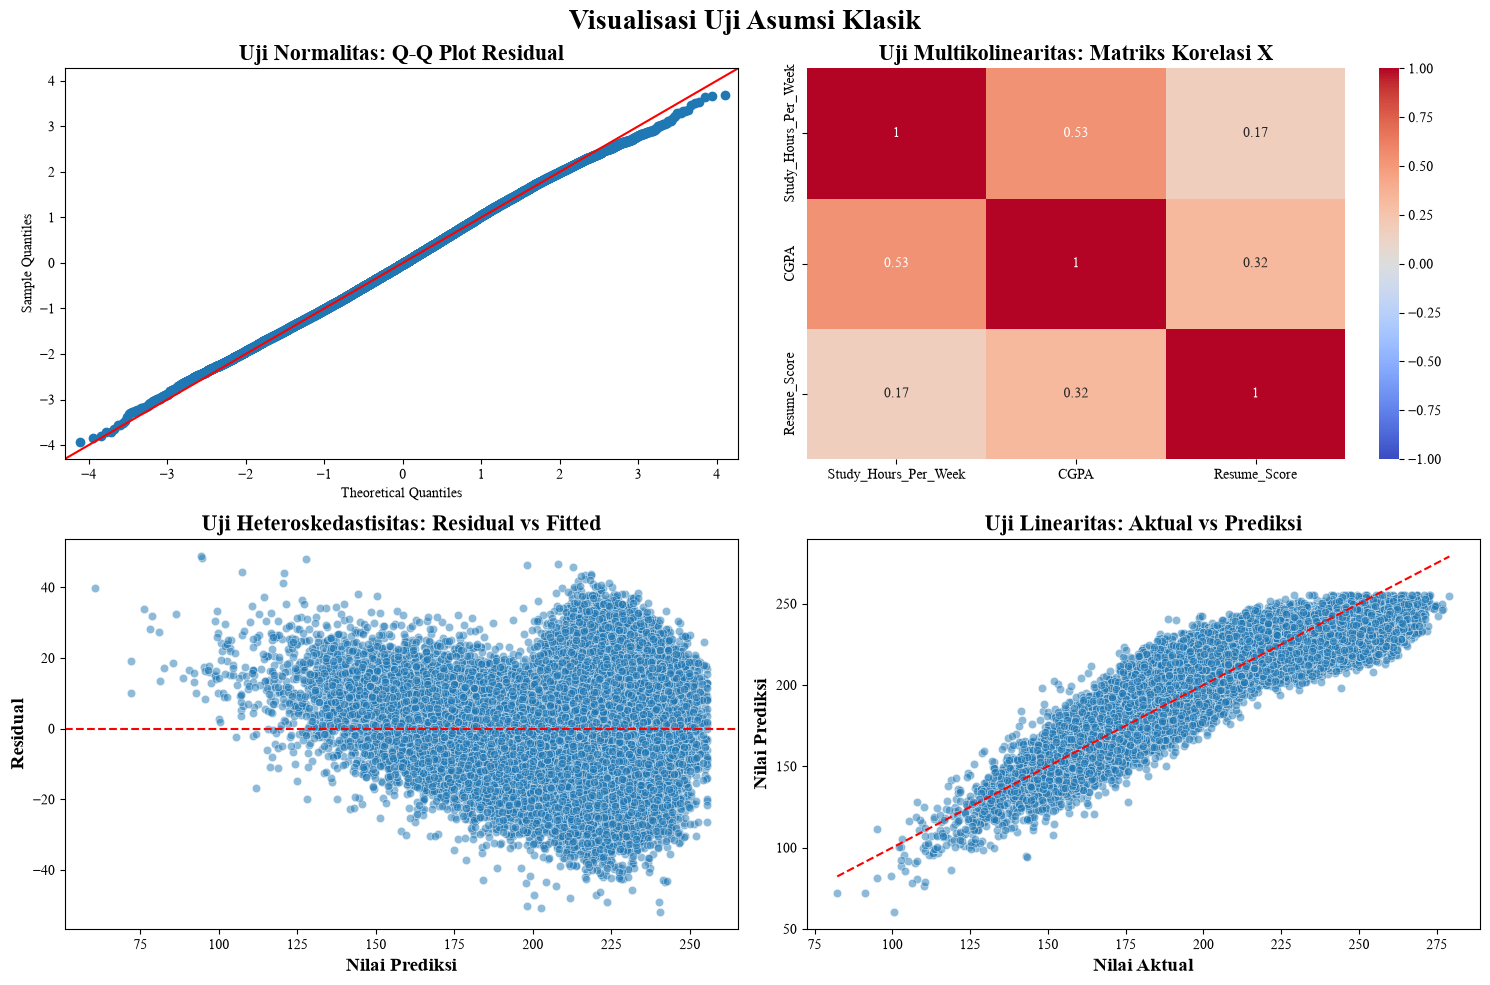

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.rcParams["font.family"] = "Times New Roman"
fig.suptitle('Visualisasi Uji Asumsi Klasik', fontsize=20, fontweight="bold")

# normalitas residual: Q-Q plot, Jarque-Bera
sm.qqplot(residuals, line='45', fit=True, ax=axes[0, 0])
axes[0, 0].set_title('Uji Normalitas: Q-Q Plot Residual', fontsize=16, fontweight="bold")
jb_pval = model.pvalues.get('Jarque-Bera', 'N/A (Lihat summary untuk N besar)')
print(f"1. Uji normalitas")
print("Q-Q Plot: Jika titik mengikuti garis merah, maka residual berdistribusi normal.\n")

# multikolinearitas
print(f"2. Uji multikolinearitas")
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data[1:])
print("Syarat terpenuhi jika nilai VIF < 10.\n")
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', ax=axes[0, 1], vmin=-1, vmax=1)
axes[0, 1].set_title('Uji Multikolinearitas: Matriks Korelasi X', fontsize=16, fontweight="bold")

# heteroskedastisitas: scatter plot, breusch-pagan
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.5, ax=axes[1, 0])
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Nilai Prediksi', fontsize=14, fontweight="bold")
axes[1, 0].set_ylabel('Residual', fontsize=14, fontweight="bold")
axes[1, 0].set_title('Uji Heteroskedastisitas: Residual vs Fitted', fontsize=16, fontweight="bold")

_, pval_bp, _, _ = het_breuschpagan(residuals, X_const)
print(f"3. Uji heteroskedsatisitas")
print("Secara visual, pastikan titik-titik menyebar secara acak.\n")

# linearitas: scatter plot Aktual vs Prediksi
sns.scatterplot(x=Y, y=fitted_values, alpha=0.5, ax=axes[1, 1])
axes[1, 1].plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', linestyle='--')
axes[1, 1].set_xlabel('Nilai Aktual', fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel('Nilai Prediksi', fontsize=14, fontweight="bold")
axes[1, 1].set_title('Uji Linearitas: Aktual vs Prediksi', fontsize=16, fontweight="bold")

print(f"4. Uji linearitas")
print("Hubungan dianggap linear jika sebaran data aktual vs prediksi mengikuti garis diagonal lurus.\n")

plt.tight_layout()
plt.show()

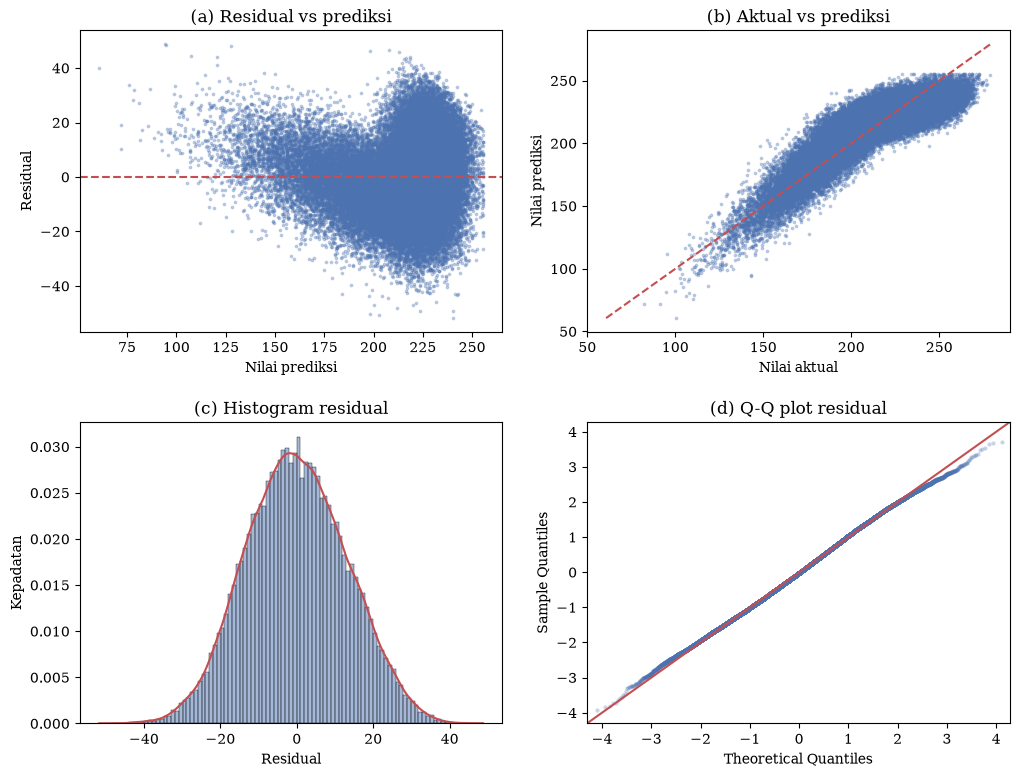

In [ ]:
model = sm.OLS(y, X_const).fit()
y_pred = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.subplots_adjust(hspace=0.3, wspace=0.2)

scatter_color = '#4c72b0'
line_color = '#c44e52'

# (a): residual vs prediksi
axes[0, 0].scatter(y_pred, residuals, alpha=0.3, s=3, color=scatter_color)
axes[0, 0].axhline(0, color=line_color, linestyle='--')
axes[0, 0].set_title('(a) Residual vs prediksi', fontsize=12)
axes[0, 0].set_xlabel('Nilai prediksi')
axes[0, 0].set_ylabel('Residual')

# (b): aktual vs prediksi
axes[0, 1].scatter(y, y_pred, alpha=0.3, s=3, color=scatter_color)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], color=line_color, linestyle='--')
axes[0, 1].set_title('(b) Aktual vs prediksi', fontsize=12)
axes[0, 1].set_xlabel('Nilai aktual')
axes[0, 1].set_ylabel('Nilai prediksi')

# (c): histogram residual
sns.histplot(residuals, kde=True, ax=axes[1, 0], color=scatter_color, stat="density", line_kws={'color': line_color})
axes[1, 0].lines[0].set_color(line_color)
axes[1, 0].set_title('(c) Histogram residual', fontsize=12)
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Kepadatan')

# (d): Q-Q plot residual
sm.qqplot(residuals, line='45', ax=axes[1, 1], fit=True, markerfacecolor=scatter_color, markeredgecolor='none', alpha=0.3, markersize=3)
axes[1, 1].get_lines()[1].set_color(line_color)
axes[1, 1].set_title('(d) Q-Q plot residual', fontsize=12)
axes[1, 1].set_xlabel('Theoretical Quantiles')
axes[1, 1].set_ylabel('Sample Quantiles')

plt.show()

## 5.6 Ringkasan

In [ ]:
# model
model = sm.OLS(y, X_const).fit()

# koefisien terstandarisasi
std_y = y.std()
std_x = X.std()
beta_unstd = model.params[cols_x]
koef_std = beta_unstd * (std_x / std_y)

In [ ]:
# linearitas
reset_test = reset_ramsey(model, degree=2)
reset_stat = reset_test.fvalue
reset_pval = reset_test.pvalue
df1_reset = reset_test.df_num
df2_reset = reset_test.df_denom
f_crit = stats.f.ppf(0.95, df1_reset, df2_reset)

# normalitas residual
jb_stat, jb_pval, _, _ = sm.stats.stattools.jarque_bera(model.resid)
chi2_crit_2 = stats.chi2.ppf(0.95, 2) # df = 2 untuk Jarque-Bera

# homoskedastisitas
bp_test = smd.het_breuschpagan(model.resid, model.model.exog)
bp_stat = bp_test[0]
bp_pval = bp_test[1]
df_bp = model.df_model
chi2_crit_bp = stats.chi2.ppf(0.95, df_bp)

# nonmultikolinearitas
vif_vals = [variance_inflation_factor(X_const.values, i) for i in range(1, X_const.shape[1])]
vif_str = "; ".join([f"{v:.3f}".replace('.', ',') for v in vif_vals])


# format
def format_stat(val):
    return f"{val:,.4f}".replace(',', 'X').replace('.', ',').replace('X', '.')

def format_pval(p):
    if pd.isna(p): return "—"
    if p < 0.0001: return "< 0,0001"
    return f"{p:.4f}".replace('.', ',')

df2_reset_str = f"{df2_reset:,.0f}".replace(',', '.')


# tabel
tabel_asumsi = pd.DataFrame({
    'Asumsi': [
        'Linearitas', 
        'Normalitas residual', 
        'Homoskedastisitas', 
        'Non-multikolinearitas'
    ],
    'Uji': [
        'Ramsey RESET (F)', 
        'Jarque-Bera', 
        'Breusch-Pagan (LM)', 
        'VIF'
    ],
    'Statistik': [
        format_stat(reset_stat), 
        format_stat(jb_stat), 
        format_stat(bp_stat), 
        vif_str
    ],
    'Nilai kritis': [
        f"{format_stat(f_crit)} (df {int(df1_reset)}; {df2_reset_str})",
        f"{format_stat(chi2_crit_2)} (χ²; df 2)",
        f"{format_stat(chi2_crit_bp)} (df {int(df_bp)})",
        "< 10"
    ],
    'p-value': [
        format_pval(reset_pval), 
        format_pval(jb_pval), 
        format_pval(bp_pval), 
        "—"
    ],
    'Keputusan': [
        'Tolak H₀' if reset_pval < 0.05 else 'Gagal tolak H₀',
        'Tolak H₀' if jb_pval < 0.05 else 'Gagal tolak H₀',
        'Tolak H₀' if bp_pval < 0.05 else 'Gagal tolak H₀',
        'Terpenuhi' if max(vif_vals) < 10 else 'Tidak terpenuhi'
    ]
})

styled_table = tabel_asumsi.style.set_properties(**{'text-align': 'right'}) \
    .set_properties(subset=['Asumsi', 'Uji', 'Keputusan'], **{'text-align': 'left'}) \
    .set_properties(subset=['p-value'], **{'text-align': 'center'}) \
    .hide(axis='index')

display(styled_table)

Asumsi,Uji,Statistik,Nilai kritis,p-value,Keputusan
Linearitas,Ramsey RESET (F),"3.061,0769","3,8416 (df 1; 49.995)","< 0,0001",Tolak H₀
Normalitas residual,Jarque-Bera,"126,0450","5,9915 (χ²; df 2)","< 0,0001",Tolak H₀
Homoskedastisitas,Breusch-Pagan (LM),"192,4713","7,8147 (df 3)","< 0,0001",Tolak H₀
Non-multikolinearitas,VIF,"1,397; 1,518; 1,117",< 10,—,Terpenuhi


In [ ]:
# r squared parsial
t_vals = model.tvalues[cols_x]
df_resid = model.df_resid
partial_r2 = (t_vals**2) / ((t_vals**2) + df_resid)

# tabel
tabel_penting = pd.DataFrame({
    'Prediktor': cols_x,
    'Koefisien terstandarisasi': koef_std.values,
    'R² parsial': partial_r2.values
})

# format
def format_desimal(val):
    return f"{val:.4f}".replace('.', ',')

tabel_penting['Koefisien terstandarisasi'] = tabel_penting['Koefisien terstandarisasi'].apply(format_desimal)
tabel_penting['R² parsial'] = tabel_penting['R² parsial'].apply(format_desimal)

styled_table = tabel_penting.style.set_properties(**{'text-align': 'right'}) \
    .set_properties(subset=['Prediktor'], **{'text-align': 'left'}) \
    .hide(axis='index')

print("Koefisien Terstandarisasi dan R² Parsial\n")
display(styled_table)

Koefisien Terstandarisasi dan R² Parsial



Prediktor,Koefisien terstandarisasi,R² parsial
Study_Hours_Per_Week,"0,0017","0,0000"
CGPA,"0,3849","0,2876"
Resume_Score,"0,6656","0,6212"


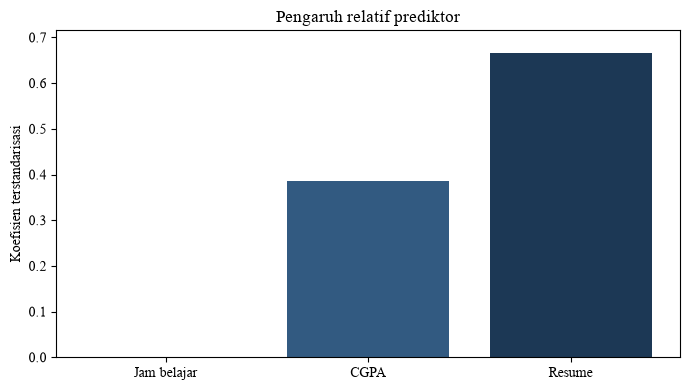

In [ ]:
# label
kategori = ['Jam belajar', 'CGPA', 'Resume']
nilai = [
    koef_std['Study_Hours_Per_Week'], 
    koef_std['CGPA'], 
    koef_std['Resume_Score']
]

fig, ax = plt.subplots(figsize=(7, 4))
warna = ['#ffffff', '#325a81', '#1c3855']
bars = ax.bar(kategori, nilai, color=warna, edgecolor='none')
ax.set_title('Pengaruh relatif prediktor', fontsize=12)
ax.set_ylabel('Koefisien terstandarisasi', fontsize=10)
ax.set_ylim(0, max(nilai) + 0.05)

plt.tight_layout()
plt.show()

# 6. Uji

## 6.1 Uji $t$

In [ ]:
# nilai statistik model
estimasi = model.params
se = model.bse
t_val = model.tvalues
p_val = model.pvalues
conf_int = model.conf_int(alpha=0.05)

# tabel
tabel_hasil = pd.DataFrame({
    'Parameter': ['Intersep (β0)', 'Study_Hours_Per_Week (β1)', 'CGPA (β2)', 'Resume_Score (β3)'],
    'Estimasi': estimasi.values,
    'SE': se.values,
    't': t_val.values,
    'p-value': p_val.values,
    'Bawah 95%': conf_int[0].values,
    'Atas 95%': conf_int[1].values
})

# format
def format_desimal(val, digit=4):
    return f"{val:.{digit}f}".replace('.', ',')

def format_pvalue(p):
    if p < 0.0001:
        return "< 0,0001"
    return format_desimal(p, 4)

tabel_hasil['Estimasi'] = tabel_hasil['Estimasi'].apply(lambda x: format_desimal(x, 4))
tabel_hasil['SE'] = tabel_hasil['SE'].apply(lambda x: format_desimal(x, 4))
tabel_hasil['t'] = tabel_hasil['t'].apply(lambda x: format_desimal(x, 2)) 
tabel_hasil['p-value'] = tabel_hasil['p-value'].apply(format_pvalue)
tabel_hasil['Bawah 95%'] = tabel_hasil['Bawah 95%'].apply(lambda x: format_desimal(x, 4))
tabel_hasil['Atas 95%'] = tabel_hasil['Atas 95%'].apply(lambda x: format_desimal(x, 4))

styled_table = tabel_hasil.style.set_properties(**{'text-align': 'right'}) \
    .set_properties(subset=['Parameter'], **{'text-align': 'left'}) \
    .hide(axis='index')

print("Uji Parsial (Uji t) dan Interval Kepercayaan\n")
display(styled_table)

Uji Parsial (Uji t) dan Interval Kepercayaan



Parameter,Estimasi,SE,t,p-value,Bawah 95%,Atas 95%
Intersep (β0),"-130,4957","0,8912","-146,42","< 0,0001","-132,2425","-128,7488"
Study_Hours_Per_Week (β1),"0,0066","0,0100","0,66","0,5076","-0,0130","0,0262"
CGPA (β2),"35,5604","0,2503","142,06","< 0,0001","35,0698","36,0511"
Resume_Score (β3),"2,4352","0,0085","286,33","< 0,0001","2,4185","2,4519"


# 7. Simulasi

In [ ]:
# dummy
skenario_data = {
    'Study_Hours_Per_Week': [15, 20, 25, 20],
    'CGPA': [2.80, 3.10, 3.50, 3.50],
    'Resume_Score': [80, 96, 100, 90]
}
df_skenario = pd.DataFrame(skenario_data)

# prediksi employability score (Ŷ)
X_skenario_const = sm.add_constant(df_skenario, has_constant='add')
y_pred = model.predict(X_skenario_const)

# tabel
tabel_prediksi = pd.DataFrame({
    'Jam belajar (X₁)': df_skenario['Study_Hours_Per_Week'],
    'CGPA (X₂)': df_skenario['CGPA'],
    'Resume (X₃)': df_skenario['Resume_Score'],
    'Prediksi Ŷ': y_pred
})

# format
tabel_prediksi['Jam belajar (X₁)'] = tabel_prediksi['Jam belajar (X₁)'].astype(int)
tabel_prediksi['CGPA (X₂)'] = tabel_prediksi['CGPA (X₂)'].apply(lambda x: f"{x:.2f}".replace('.', ','))
tabel_prediksi['Resume (X₃)'] = tabel_prediksi['Resume (X₃)'].astype(int)
tabel_prediksi['Prediksi Ŷ'] = tabel_prediksi['Prediksi Ŷ'].apply(lambda x: f"{x:.2f}".replace('.', ','))

styled_table = tabel_prediksi.style.set_properties(**{'text-align': 'right'}) \
    .set_properties(subset=['Jam belajar (X₁)'], **{'text-align': 'left'}) \
    .hide(axis='index')

print("Simulasi Prediksi Employability Score\n")
display(styled_table)

Simulasi Prediksi Employability Score



Jam belajar (X₁),CGPA (X₂),Resume (X₃),Prediksi Ŷ
15,"2,80",80,"163,99"
20,"3,10",96,"213,65"
25,"3,50",100,"237,65"
20,"3,50",90,"213,27"
